# Lezione 1 — Riconoscere differenze piccole

**Modulo 1: classificazione fine-grained e fusione immagine + tabella.**
Corso di AI applicata per Zucchetti Centro Sistemi, 2 settembre 2026.

Il notebook si esegue dall'alto in basso. Ci sono **tre celle marcate `PUNTO DI VARIAZIONE`**:
sono le uniche che si toccano, cambiando la costante sulla prima riga e rieseguendo.

---

### I dati

**CUB-200-2011**, sottoinsieme di 20 classi: 8 gabbiani, 7 sterne, 5 martin pescatori.

> Wah C., Branson S., Welinder P., Perona P., Belongie S.
> *The Caltech-UCSD Birds-200-2011 Dataset.*
> Computation & Neural Systems Technical Report CNS-TR-2011-001,
> California Institute of Technology, 2011.

Fonte: <https://www.vision.caltech.edu/datasets/cub_200_2011/>.
I termini della fonte limitano l'uso a **ricerca e didattica non commerciali**.
Questo sottoinsieme è ridistribuito per la didattica di questo corso e non va usato per
scopi commerciali. Le immagini **non** compaiono nel PDF delle slide, per lo stesso motivo.

In [1]:
# Cella 0 — dati e librerie. Gira una volta sola, circa un minuto.
import os, sys, tarfile, urllib.request, pathlib, time, math, warnings
warnings.filterwarnings("ignore")

URL = ("https://github.com/nunziati/zcs-ai-course-2026/releases/download/"
       "dati-cub/cub-200-2011-20-classi.tgz")
RADICE = pathlib.Path("dati")

if not (RADICE / "CUB_200_2011" / "images.txt").exists():
    RADICE.mkdir(exist_ok=True)
    print("scarico 65 MB...")
    urllib.request.urlretrieve(URL, RADICE / "cub.tgz")
    with tarfile.open(RADICE / "cub.tgz") as t:
        t.extractall(RADICE)
    print("fatto")

D = RADICE / "CUB_200_2011"

import numpy as np, pandas as pd, torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image

DISPOSITIVO = "cuda" if torch.cuda.is_available() else "cpu"
if DISPOSITIVO == "cpu":
    torch.set_num_threads(os.cpu_count())
print(f"torch {torch.__version__} su {DISPOSITIVO}")
if DISPOSITIVO == "cpu":
    print("Nessuna GPU: gira lo stesso, l'estrazione delle feature costa circa un minuto")
    print("invece di quindici secondi. Su Colab: Runtime > Cambia tipo di runtime > T4.")

torch 2.13.0+cpu su cpu
Nessuna GPU: gira lo stesso, l'estrazione delle feature costa circa un minuto
invece di quindici secondi. Su Colab: Runtime > Cambia tipo di runtime > T4.


---

# Passo 2 — Dati

Prima di qualsiasi modello: cosa c'è dentro, e cosa c'è dentro che **non dovrebbe** essere usato.

In [2]:
# I metadati. Sono file di testo con una riga per immagine.
immagini = pd.read_csv(D/"images.txt", sep=" ", names=["id", "file"])
etichette = pd.read_csv(D/"image_class_labels.txt", sep=" ", names=["id", "classe"])
split     = pd.read_csv(D/"train_test_split.txt", sep=" ", names=["id", "train"])
classi    = pd.read_csv(D/"classes.txt", sep=" ", names=["classe", "nome"])

dati = immagini.merge(etichette, on="id").merge(split, on="id").merge(classi, on="classe")

# TRAPPOLA: gli id di classe NON sono contigui — 59-66, 79-83, 141-147.
# Senza rimappatura la cross-entropy si aspetta 148 classi e il training fallisce
# senza dire perche'. Una riga:
dati["y"], nomi_classe = pd.factorize(dati["nome"].sort_values().values, sort=True)
dati = dati.sort_values("nome").reset_index(drop=True)

print(f"{len(dati)} immagini, {len(nomi_classe)} classi")
print(f"train {int(dati.train.sum())}  test {int((1-dati.train).sum())}")
print(f"\nid di classe originali: {sorted(dati.classe.unique().tolist())}")
print(f"rimappati in: 0..{dati.y.max()}")

1187 immagini, 20 classi
train 599  test 588

id di classe originali: [59, 60, 61, 62, 63, 64, 65, 66, 79, 80, 81, 82, 83, 141, 142, 143, 144, 145, 146, 147]
rimappati in: 0..19


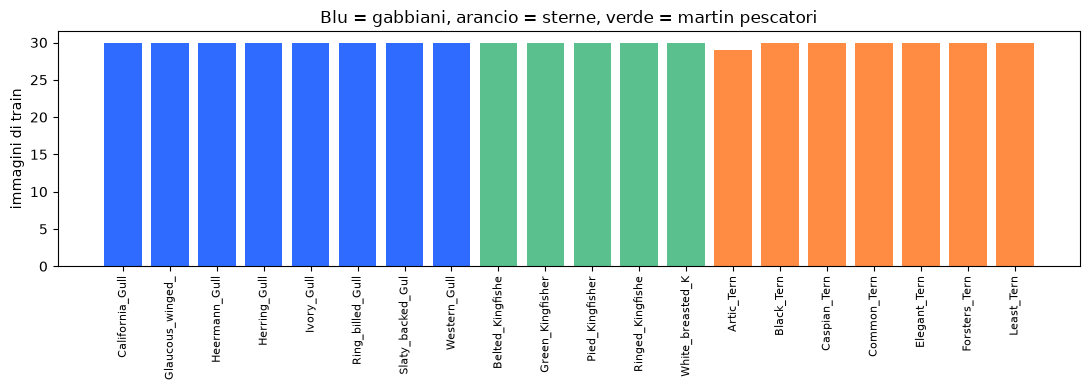

minimo 29, massimo 30 -> CUB e' bilanciato.
Il catalogo di un'azienda non lo e' mai. Ci torniamo alle 10:50.


In [3]:
# Quante immagini per classe. Tenere a mente questo istogramma: torna alle 10:50.
conteggio = dati[dati.train == 1].groupby("nome").size()
fig, ax = plt.subplots(figsize=(11, 4))
colori = ["#2f6bff" if "Gull" in n else "#ff8c42" if "Tern" in n else "#5ac18e"
          for n in conteggio.index]
ax.bar(range(len(conteggio)), conteggio.values, color=colori)
ax.set_xticks(range(len(conteggio)))
ax.set_xticklabels([n.split(".")[1][:16] for n in conteggio.index], rotation=90, fontsize=8)
ax.set_ylabel("immagini di train")
ax.set_title("Blu = gabbiani, arancio = sterne, verde = martin pescatori")
plt.tight_layout(); plt.show()
print(f"minimo {conteggio.min()}, massimo {conteggio.max()} -> CUB e' bilanciato.")
print("Il catalogo di un'azienda non lo e' mai. Ci torniamo alle 10:50.")

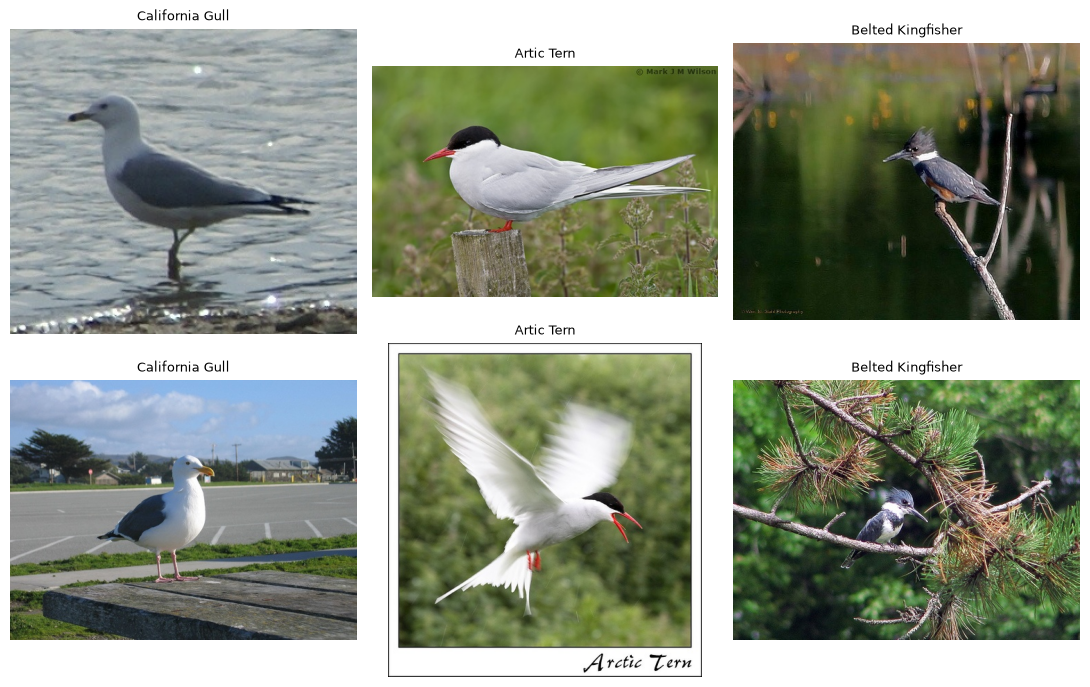

In [4]:
# Le immagini. Un gabbiano, una sterna, un martin pescatore.
scelte = [dati[dati.nome.str.contains(g)].iloc[i]
          for g in ("Gull", "Tern", "Kingfisher") for i in (0, 40)]
fig, assi = plt.subplots(2, 3, figsize=(11, 7))
for a, r in zip(assi.T.ravel(), scelte):
    a.imshow(Image.open(D/"images"/r.file)); a.axis("off")
    a.set_title(r.nome.split(".")[1].replace("_", " "), fontsize=9)
plt.tight_layout(); plt.show()

## Il vettore numerico: geometria, non attributi

Il dataset contiene **312 attributi** — `has_bill_shape::dagger`, `has_wing_color::white` —
ed è la cosa che verrebbe naturale usare come "tabella" da fondere con l'immagine.
**Non li useremo**, e la cella qui sotto mostra due motivi diversi, uno per ciascuno dei due
file in cui gli attributi sono scritti.

Vale la pena guardarla con attenzione: **la trappola non è che gli attributi siano cattivi.
È che uno dei due file non è una feature ma l'etichetta riscritta**, e i due file si
chiamano quasi allo stesso modo.

In [5]:
# I 312 attributi stanno in DUE file diversi, e la differenza e' tutto.
from sklearn.linear_model import LogisticRegression
m = dati.train.values == 1

# (a) per CLASSE: una riga per specie, uguale per tutte le sue immagini
per_classe = np.array([list(map(float, r.split()))
                       for r in open(D/"attributes/class_attribute_labels_continuous.txt")])
Xa = per_classe[dati.y.values]
a1 = 100 * LogisticRegression(max_iter=3000).fit(Xa[m], dati.y[m]).score(Xa[~m], dati.y[~m])
print(f"(a) attributi PER CLASSE  -> {a1:.1f}%")
print(f"    righe distinte: {len(np.unique(per_classe, axis=0))} per {len(nomi_classe)} classi")

# (b) per IMMAGINE: quello che l'annotatore ha visto in QUELLA foto
attr = pd.read_csv(D/"attributes/image_attribute_labels.txt", sep=" ",
                   usecols=[0, 1, 2], names=["id", "attr", "presente"], on_bad_lines="skip")
Xb = attr.pivot_table(index="id", columns="attr", values="presente",
                      fill_value=0).reindex(dati.id.values).fillna(0)
a2 = 100 * LogisticRegression(max_iter=3000).fit(Xb[m], dati.y[m]).score(Xb[~m], dati.y[~m])
print(f"(b) attributi PER IMMAGINE -> {a2:.1f}%")
print()
print("Il primo file NON e' una feature: e' l'etichetta scritta in un altro alfabeto.")
print("Venti righe distinte per venti classi, quindi la specie e' determinata.")
print("Chi lo usa per sbaglio ottiene il 100% e crede di avere un modello.")
print()
print("Il secondo e' onesto ma fa PEGGIO dell'immagine: sono descrizioni umane rumorose.")
print("E nessuno dei due ha la forma del problema di ZCS, dove il numero e' una misura")
print("presa da uno strumento, non un umano che descrive l'oggetto che ha gia' riconosciuto.")

(a) attributi PER CLASSE  -> 100.0%
    righe distinte: 20 per 20 classi


(b) attributi PER IMMAGINE -> 55.3%

Il primo file NON e' una feature: e' l'etichetta scritta in un altro alfabeto.
Venti righe distinte per venti classi, quindi la specie e' determinata.
Chi lo usa per sbaglio ottiene il 100% e crede di avere un modello.

Il secondo e' onesto ma fa PEGGIO dell'immagine: sono descrizioni umane rumorose.
E nessuno dei due ha la forma del problema di ZCS, dove il numero e' una misura
presa da uno strumento, non un umano che descrive l'oggetto che ha gia' riconosciuto.


In [6]:
# Il vettore che useremo: 12 misure geometriche dalle coordinate delle parti e dal box.
parti = pd.read_csv(D/"parts/part_locs.txt", sep=" ",
                    names=["id", "parte", "x", "y", "visibile"])
box = pd.read_csv(D/"bounding_boxes.txt", sep=" ", names=["id", "bx", "by", "bw", "bh"])

BECCO, PANCIA, PETTO, CORONA, FRONTE, NUCA, CODA, GOLA = 2, 3, 4, 5, 6, 10, 14, 15
AFFIDABILI = [BECCO, PANCIA, PETTO, CORONA, FRONTE, NUCA, CODA, GOLA]

# Solo le parti visibili. Ali e occhi sono annotati in due terzi e meta' delle immagini:
# una feature che manca un terzo delle volte e' peggio di una feature che non hai.
viste = parti[parti.visibile == 1]
P = {p: viste[viste.parte == p].set_index("id")[["x", "y"]] for p in AFFIDABILI}
B = box.set_index("id")

def dist(a, b, ids):
    pa, pb = P[a].reindex(ids), P[b].reindex(ids)
    return np.hypot(pa.x - pb.x, pa.y - pb.y).values

ids = dati.id.values
bw, bh = B.reindex(ids).bw.values, B.reindex(ids).bh.values
dim = np.array([Image.open(D/"images"/f).size for f in dati.file])
corpo = dist(BECCO, CODA, ids)
r = lambda a, b: dist(a, b, ids) / corpo

G = pd.DataFrame({
    # grezze: dipendono dalla distanza dello scatto
    "corpo_px": corpo,
    "radice_area_box_px": np.sqrt(bw * bh),
    # rapporti: invarianti alla distanza
    "corpo_su_diagonale": corpo / np.hypot(bw, bh),
    "becco_su_corpo": r(BECCO, FRONTE),
    "testa_su_corpo": r(CORONA, GOLA),
    "becco_nuca_su_corpo": r(BECCO, NUCA),
    "petto_pancia_su_corpo": r(PETTO, PANCIA),
    "gola_coda_su_corpo": r(GOLA, CODA),
    "corona_fronte_su_corpo": r(CORONA, FRONTE),
    "box_aspetto": bw / bh,
    "box_su_immagine": (bw * bh) / (dim[:, 0] * dim[:, 1]),
    "parti_viste": sum(P[p].reindex(ids).x.notna().values for p in AFFIDABILI) / len(AFFIDABILI),
})
print(f"vettore geometrico: {G.shape[1]} misure per immagine")
print("\nvalori mancanti (parte non annotata):")
print((100 * G.isna().mean()).round(1).to_string())

vettore geometrico: 12 misure per immagine

valori mancanti (parte non annotata):
corpo_px                   2.5
radice_area_box_px         0.0
corpo_su_diagonale         2.5
becco_su_corpo             4.3
testa_su_corpo             5.1
becco_nuca_su_corpo        5.7
petto_pancia_su_corpo     11.3
gola_coda_su_corpo         4.0
corona_fronte_su_corpo     5.2
box_aspetto                0.0
box_su_immagine            0.0
parti_viste                0.0


In [7]:
# I mancanti si riempiono con la mediana del TRAIN, mai di tutto il dataset.
# Poi si standardizza, sempre con statistiche del solo train.
mediane = G[m].median()
G = G.fillna(mediane)
mu, sd = G[m].mean(), G[m].std() + 1e-8
Gz = ((G - mu) / sd).astype("float32")

# Quanto vale da solo questo vettore? Poco, ed e' giusto cosi'.
clf = LogisticRegression(max_iter=2000).fit(Gz[m], dati.y[m])
print(f"accuratezza sulle sole 12 misure: {100*clf.score(Gz[~m], dati.y[~m]):.1f}%")
print(f"(tirare a caso: {100/len(nomi_classe):.0f}%)")
print("\nUn po' di segnale c'e', ma non e' un classificatore. Serve accanto all'immagine,")
print("non al posto suo. E ATTENZIONE alle prime due righe: sono in pixel, quindi")
print("dipendono da quanto era lontano il fotografo. Le misure di ZCS sono millimetri")
print("veri presi da uno strumento: il loro caso e' piu' facile del nostro.")

accuratezza sulle sole 12 misure: 24.1%
(tirare a caso: 5%)

Un po' di segnale c'e', ma non e' un classificatore. Serve accanto all'immagine,
non al posto suo. E ATTENZIONE alle prime due righe: sono in pixel, quindi
dipendono da quanto era lontano il fotografo. Le misure di ZCS sono millimetri
veri presi da uno strumento: il loro caso e' piu' facile del nostro.


## Augmentation: quali hanno senso qui

ZCS fotografa su piano bianco, luce fissa, un oggetto per scatto. **L'acquisizione è
controllata**, quindi metà delle augmentation classiche inventano un dominio che nella loro
realtà non esiste — e la rete spende capacità per imparare a essere invariante a qualcosa
che non incontrerà mai.

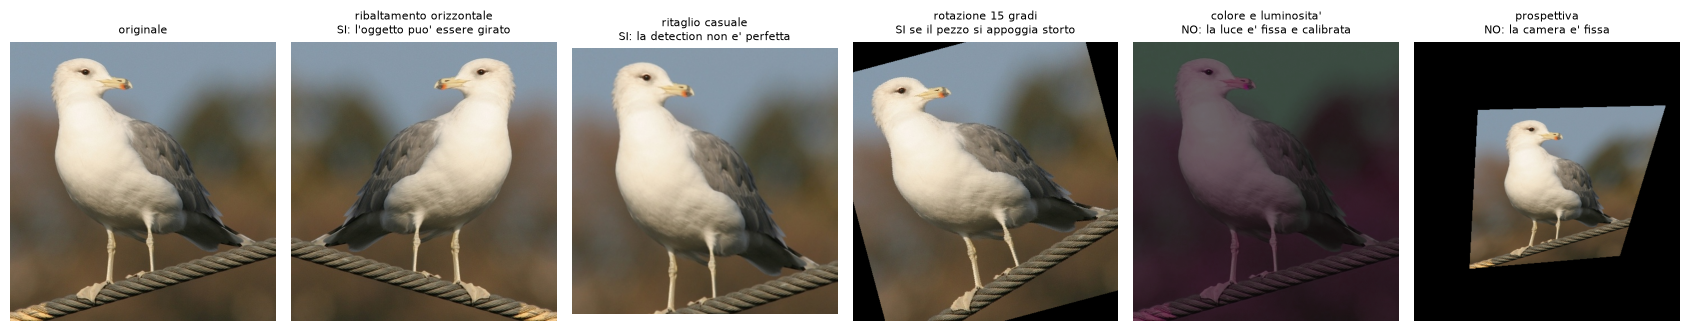

In [8]:
from torchvision import transforms
esempio = Image.open(D/"images"/dati.file.iloc[3])

prove = {
    "originale": lambda im: im,
    "ribaltamento orizzontale\nSI: l'oggetto puo' essere girato": transforms.RandomHorizontalFlip(1.0),
    "ritaglio casuale\nSI: la detection non e' perfetta": transforms.RandomResizedCrop(300, scale=(0.7, 0.9)),
    "rotazione 15 gradi\nSI se il pezzo si appoggia storto": transforms.RandomRotation((15, 15)),
    "colore e luminosita'\nNO: la luce e' fissa e calibrata": transforms.ColorJitter(0.6, 0.6, 0.6, 0.2),
    "prospettiva\nNO: la camera e' fissa": transforms.RandomPerspective(0.5, 1.0),
}
fig, assi = plt.subplots(1, len(prove), figsize=(17, 3.6))
for a, (nome, t) in zip(assi, prove.items()):
    a.imshow(t(esempio)); a.axis("off"); a.set_title(nome, fontsize=8)
plt.tight_layout(); plt.show()

---

# Passo 3 — Dalla baseline al metodo

**La domanda della giornata non è «come si costruisce un classificatore fine-grained».**
Voi ArcFace ce l'avete già in produzione. La domanda è: *cosa giri quando ArcFace c'è già
e non basta?*

Le risposte sono tre, e le vediamo in ordine di **costo crescente di quello che cambi**:

1. un iperparametro — margine e scala;
2. la regola di decisione, senza riaddestrare niente;
3. il dato — la fusione con le misure.

## Il trucco che rende possibili quattro esperimenti in settanta minuti

Il backbone resta **congelato**. Le sue uscite si calcolano **una volta sola** e si tengono
in memoria: 1187 vettori da 1280 numeri. Da lì ogni esperimento allena solo una testa su
599 vettori, e costa **secondi**. È un espediente d'aula, non come si lavora in produzione:
a fine giornata il numero vero lo dà un fine-tuning completo.

In [9]:
# Estrazione delle feature. UNA VOLTA SOLA: circa 15 s su GPU, un minuto su CPU.
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

pesi = EfficientNet_B0_Weights.IMAGENET1K_V1
rete = efficientnet_b0(weights=pesi).eval().to(DISPOSITIVO)
tronco = nn.Sequential(rete.features, rete.avgpool, nn.Flatten()).eval()
for q in tronco.parameters():
    q.requires_grad_(False)

prep = transforms.Compose([
    transforms.Resize(256), transforms.CenterCrop(224), transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

t0 = time.time(); pezzi = []; lotto = []
for n, f in enumerate(dati.file, 1):
    lotto.append(prep(Image.open(D/"images"/f).convert("RGB")))
    if len(lotto) == 32 or n == len(dati):
        with torch.no_grad():
            pezzi.append(tronco(torch.stack(lotto).to(DISPOSITIVO)).cpu())
        lotto = []

E = torch.cat(pezzi)
print(f"{E.shape[0]} embedding da {E.shape[1]} numeri in {time.time()-t0:.0f}s")

tr = torch.tensor(dati.train.values == 1)
Y  = torch.tensor(dati.y.values).long()
Gt = torch.tensor(Gz.values)
Xtr, Xte = E[tr], E[~tr]
Gtr, Gte = Gt[tr], Gt[~tr]
ytr, yte = Y[tr], Y[~tr]
NCLASSI = len(nomi_classe)
print(f"train {len(ytr)}  test {len(yte)}")

1187 embedding da 1280 numeri in 57s
train 599  test 588


In [10]:
# ArcFace in venti righe. E' tutto qui.
class ArcFace(nn.Module):
    def __init__(self, dim, classi, margine=0.5, scala=32.0):
        super().__init__()
        self.W = nn.Parameter(torch.randn(classi, dim) * 0.01)
        self.margine, self.scala = margine, scala

    def forward(self, x, y=None):
        # embedding e pesi normalizzati: il logit E' il coseno dell'angolo
        cos = F.linear(F.normalize(x), F.normalize(self.W)).clamp(-1 + 1e-7, 1 - 1e-7)
        if y is None or self.margine == 0:
            return self.scala * cos                      # inferenza: nessun margine
        # allenamento: al solo angolo della classe giusta si somma il margine
        angolo = cos.acos() + F.one_hot(y, cos.shape[1]) * self.margine
        return self.scala * angolo.cos()


class Testa(nn.Module):
    # bottleneck + testa. iniezione: niente | prima | dopo
    def __init__(self, dim_in, dim_geo=0, dim_bott=128, arcface=True,
                 margine=0.5, scala=32.0, iniezione="niente"):
        super().__init__()
        self.iniezione, self.arcface = iniezione, arcface
        dp = 32
        self.proj = (nn.Sequential(nn.Linear(dim_geo, dp), nn.ReLU(), nn.Linear(dp, dp))
                     if dim_geo else None)
        ingresso = dim_in + (dp if iniezione == "prima" else 0)
        self.bott = nn.Sequential(nn.Linear(ingresso, dim_bott), nn.BatchNorm1d(dim_bott))
        uscita = dim_bott + (dp if iniezione == "dopo" else 0)
        self.testa = (ArcFace(uscita, NCLASSI, margine, scala) if arcface
                      else nn.Linear(uscita, NCLASSI))

    def embedding(self, x, g=None):
        p = self.proj(g) if self.proj is not None else None
        if self.iniezione == "prima":
            x = torch.cat([x, p], 1)
        z = self.bott(x)
        if self.iniezione == "dopo":
            z = torch.cat([z, p], 1)
        return z

    def forward(self, x, g=None, y=None):
        z = self.embedding(x, g)
        return self.testa(z, y) if self.arcface else self.testa(z)


def allena(modello, X, Y_, G=None, epoche=60, lr=1e-3, seme=0):
    torch.manual_seed(seme)
    opt = torch.optim.AdamW(modello.parameters(), lr=lr, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, epoche)
    storia = []
    for _ in range(epoche):
        modello.train(); idx = torch.randperm(len(Y_)); tot = 0.0
        for k in range(0, len(idx), 64):
            b = idx[k:k+64]
            if len(b) < 2:
                continue
            opt.zero_grad()
            perdita = F.cross_entropy(modello(X[b], G[b] if G is not None else None, Y_[b]),
                                      Y_[b], label_smoothing=0.1)
            perdita.backward(); opt.step(); tot += perdita.item() * len(b)
        sched.step(); storia.append(tot / len(Y_))
    return storia


@torch.no_grad()
def predici(modello, X, G=None):
    modello.eval(); return modello(X, G).argmax(1)

@torch.no_grad()
def embeddings(modello, X, G=None):
    modello.eval(); return F.normalize(modello.embedding(X, G))

def accuratezza(p, y): return 100 * (p == y).float().mean().item()

In [11]:
# Come si dice se una differenza e' vera. Serve tutto il giorno, si scrive adesso.
def mcnemar(pred_a, pred_b, y):
    '''Confronta due modelli sullo STESSO test set. Guarda solo i disaccordi.'''
    ok_a, ok_b = (pred_a == y), (pred_b == y)
    solo_a = int((ok_a & ~ok_b).sum())     # giuste per A, sbagliate per B
    solo_b = int((ok_b & ~ok_a).sum())     # il contrario
    n = solo_a + solo_b
    if n == 0:
        return solo_a, solo_b, 1.0
    chi = (abs(solo_a - solo_b) - 1) ** 2 / n          # correzione di continuita'
    return solo_a, solo_b, math.erfc(math.sqrt(chi / 2))

def confronta(nome, pred_new, pred_rif, y=None):
    y = yte if y is None else y
    riga = f"{nome:44} {accuratezza(pred_new, y):6.2f}%"
    if pred_rif is not None:
        a, b, p = mcnemar(pred_rif, pred_new, y)
        verdetto = "DIFFERENZA VERA" if p < 0.05 else "dentro il rumore"
        riga += f"   +{b:2d} -{a:2d}  disaccordi {a+b:3d}  p={p:.3f}  {verdetto}"
    print(riga)

### 10:30 — Il punto di partenza

Stesse feature, due teste: softmax normale e ArcFace. **Questo è il gradino che avete già
salito.** Guardate il verdetto della seconda riga prima di guardare le percentuali.

In [12]:
# Con differenze di un punto, UN SOLO seme e' rumore. Tre semi, e si guarda anche
# quanto balla il risultato cambiando solo l'inizializzazione.
def su_tre_semi(fabbrica, X=None, G=None):
    X = Xtr if X is None else X
    acc_, pr = [], []
    for seme in (0, 1, 2):
        mod = fabbrica(); allena(mod, X, ytr, G, seme=seme)
        p = predici(mod, Xte, Gte if G is not None else None)
        acc_.append(accuratezza(p, yte)); pr.append(p)
    return float(np.mean(acc_)), float(np.std(acc_)), pr[0]

a_soft, s_soft, p_soft = su_tre_semi(lambda: Testa(1280, arcface=False))
a_arc,  s_arc,  p_arc  = su_tre_semi(lambda: Testa(1280, arcface=True, margine=0.5))

print(f"softmax (label smoothing 0.1)      {a_soft:6.2f}%  +/- {s_soft:.2f} sul seme")
print(f"ArcFace margine 0.5 scala 32       {a_arc:6.2f}%  +/- {s_arc:.2f} sul seme")
print()
confronta("un singolo confronto, seme 0", p_arc, p_soft)
print(f"\nLo scarto fra le due teste e' {abs(a_arc-a_soft):.2f} punti.")
print(f"Il solo cambio di inizializzazione ne sposta {max(s_soft,s_arc):.2f}.")
print()
print("Su QUESTI dati le due teste pareggiano. Non e' un errore della demo:")
print("con il backbone congelato e 599 vettori di train, il margine non ha")
print("abbastanza dati per costruire una geometria migliore.")
print()
print("La cosa da portarsi via non e' 'ArcFace non serve'. E' che la domanda")
print("'mi serve?' si risponde con la riga dei disaccordi, non con le percentuali.")

softmax (label smoothing 0.1)       67.97%  +/- 0.29 sul seme
ArcFace margine 0.5 scala 32        67.40%  +/- 0.21 sul seme

un singolo confronto, seme 0                  67.35%   +20 -23  disaccordi  43  p=0.760  dentro il rumore

Lo scarto fra le due teste e' 0.57 punti.
Il solo cambio di inizializzazione ne sposta 0.29.

Su QUESTI dati le due teste pareggiano. Non e' un errore della demo:
con il backbone congelato e 599 vettori di train, il margine non ha
abbastanza dati per costruire una geometria migliore.

La cosa da portarsi via non e' 'ArcFace non serve'. E' che la domanda
'mi serve?' si risponde con la riga dei disaccordi, non con le percentuali.


### 10:40 — Cambia un iperparametro: margine e scala

Il margine si somma **all'angolo**, in radianti: `0.5` sono 28,6 gradi. Il margine di
CosFace invece si sottrae al coseno ed è un numero puro: **i due valori non sono
confrontabili**, e scambiarli è l'errore più comune.

Prima di girarlo, un conto. All'inizio del training gli embedding sono a circa 90 gradi dai
pesi, quindi il logit della classe giusta vale `scala · cos(90° + margine)` mentre tutti gli
altri valgono zero. Più margine metti, più il punto di partenza è disperato.

In [13]:
print(f"{'margine':>8} {'gradi':>7} {'logit iniziale':>15} {'p(classe giusta)':>18} {'loss iniziale':>14}")
for mm in (0.0, 0.35, 0.5, 0.9, 1.2, 1.5, 2.1):
    logit = 32.0 * math.cos(math.pi/2 + mm)
    p = math.exp(logit) / (math.exp(logit) + NCLASSI - 1)
    print(f"{mm:>8.2f} {math.degrees(mm):>7.1f} {logit:>15.1f} {p:>18.2e} {-math.log(p):>14.1f}")
print()
print("Notare l'ultima riga: a margine 2.1 l'angolo con il margine supera 180 gradi,")
print("il coseno RICOMINCIA A SALIRE e la loss smette di penalizzare. Teniamolo a mente.")

 margine   gradi  logit iniziale   p(classe giusta)  loss iniziale
    0.00     0.0             0.0           5.00e-02            3.0
    0.35    20.1           -11.0           9.03e-07           13.9
    0.50    28.6           -15.3           1.14e-08           18.3
    0.90    51.6           -25.1           6.84e-13           28.0
    1.20    68.8           -29.8           5.87e-15           32.8
    1.50    85.9           -31.9           7.22e-16           34.9
    2.10   120.3           -27.6           5.31e-14           30.6

Notare l'ultima riga: a margine 2.1 l'angolo con il margine supera 180 gradi,
il coseno RICOMINCIA A SALIRE e la loss smette di penalizzare. Teniamolo a mente.


In [14]:
# ============================================================================
# PUNTO DI VARIAZIONE 1 — cambia il numero, riesegui questa cella e la prossima
# ============================================================================
MARGINE = 0.5
# ============================================================================

mod = Testa(1280, arcface=True, margine=MARGINE)
storia = allena(mod, Xtr, ytr)
p_var = predici(mod, Xte)

print(f"margine {MARGINE}  ({math.degrees(MARGINE):.1f} gradi)")
print(f"  loss iniziale {storia[0]:8.2f}")
print(f"  loss finale   {storia[-1]:8.3f}")
print(f"  accuratezza   {accuratezza(p_var, yte):7.2f}%")

margine 0.5  (28.6 gradi)
  loss iniziale    15.42
  loss finale      0.815
  accuratezza     67.35%


 margine  loss_iniziale  loss_finale  accuratezza
   0.000          3.531        0.623       64.796
   0.350         11.626        0.749       66.497
   0.500         15.534        0.820       67.347
   0.700         20.640        0.866       67.517
   0.900         25.390        0.860       68.197
   1.200         30.987        1.074       67.517
   1.500         33.768        6.505       22.109
   1.800         32.766        8.836        6.122
   2.100         27.684        1.245        0.170


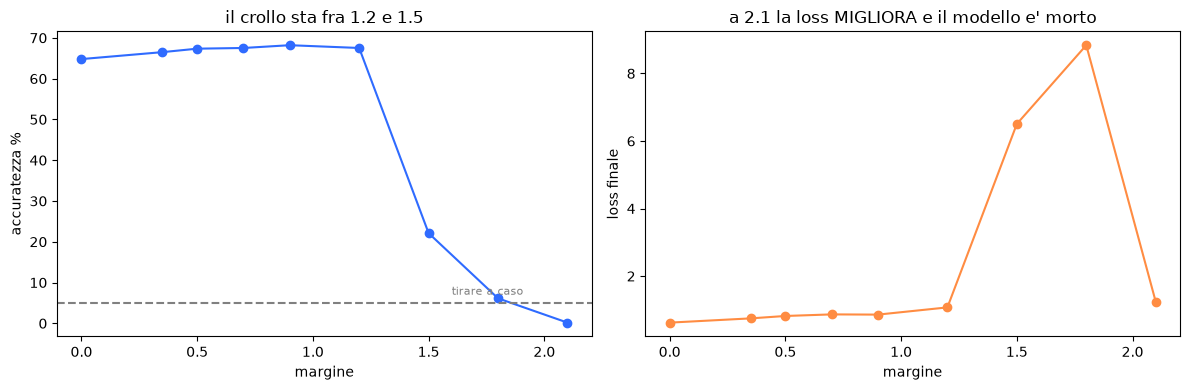

In [15]:
# Lo stesso, per tutti i margini in una volta. Serve la figura, non i singoli numeri.
righe = []
for mm in (0.0, 0.35, 0.5, 0.7, 0.9, 1.2, 1.5, 1.8, 2.1):
    m_ = Testa(1280, arcface=True, margine=mm)
    st = allena(m_, Xtr, ytr)
    righe.append((mm, st[0], st[-1], accuratezza(predici(m_, Xte), yte)))

tab = pd.DataFrame(righe, columns=["margine", "loss_iniziale", "loss_finale", "accuratezza"])
print(tab.to_string(index=False, float_format=lambda v: f"{v:8.3f}"))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
a1.plot(tab.margine, tab.accuratezza, "o-", color="#2f6bff")
a1.axhline(100/NCLASSI, ls="--", c="gray"); a1.set_xlabel("margine"); a1.set_ylabel("accuratezza %")
a1.set_title("il crollo sta fra 1.2 e 1.5"); a1.text(1.6, 100/NCLASSI+2, "tirare a caso", color="gray", fontsize=8)
a2.plot(tab.margine, tab.loss_finale, "o-", color="#ff8c42")
a2.set_xlabel("margine"); a2.set_ylabel("loss finale")
a2.set_title("a 2.1 la loss MIGLIORA e il modello e' morto")
plt.tight_layout(); plt.show()

### 10:50 — Cambia la regola di decisione, senza riaddestrare niente

Lo stesso embedding, quattro modi di decidere. Nessuno dei tre che seguono il primo tocca il
backbone né rialllena la rappresentazione.

**Prima, però, un problema del dataset.** CUB ha 29-30 immagini per classe: è bilanciato.
Un catalogo aziendale non lo è mai — avete strumenti da mille pezzi l'anno e strumenti da
tre. Su dati bilanciati queste quattro regole pareggiano e non si impara niente, quindi
**squilibriamo noi il train**, da 30 a 3 immagini per classe. È quello che fanno i paper di
long-tail per costruire ImageNet-LT. **Il test resta intatto.**

In [16]:
# Coda lunga artificiale sul solo train: la classe piu' ricca ha 30, la piu' povera 3.
rng = np.random.default_rng(0)
RAPPORTO = 10
quote = [max(3, round(30 * RAPPORTO ** (-k/(NCLASSI-1)))) for k in range(NCLASSI)]
tieni = np.sort(np.concatenate([
    rng.choice(np.where(ytr.numpy() == k)[0], size=min(q, int((ytr == k).sum())), replace=False)
    for k, q in enumerate(quote)]))

Xlt, ylt, Glt = Xtr[tieni], ytr[tieni], Gtr[tieni]
RICCHE, POVERE = list(range(7)), list(range(NCLASSI-7, NCLASSI))
print(f"train squilibrato: {len(ylt)} immagini invece di {len(ytr)}")
print(f"per classe: {quote}")

def per_gruppo(p, gruppo):
    msk = torch.zeros_like(yte, dtype=torch.bool)
    for k in gruppo:
        msk |= (yte == k)
    return 100 * (p[msk] == yte[msk]).float().mean().item()

def confronta_lt(nome, p, rif=None):
    riga = (f"{nome:38} {accuratezza(p, yte):6.2f}%"
            f"   ricche {per_gruppo(p, RICCHE):6.2f}%   povere {per_gruppo(p, POVERE):6.2f}%")
    if rif is not None:
        a, b, pv = mcnemar(rif, p, yte)
        riga += f"   p={pv:.4f}{'  VERA' if pv < 0.05 else ''}"
    print(riga)

train squilibrato: 238 immagini invece di 599
per classe: [30, 27, 24, 21, 18, 16, 14, 13, 11, 10, 9, 8, 7, 6, 5, 5, 4, 4, 3, 3]


In [17]:
base_lt = Testa(1280, arcface=True, margine=0.5)
allena(base_lt, Xlt, ylt)
p1 = predici(base_lt, Xte)
Zlt, Zte = embeddings(base_lt, Xlt), embeddings(base_lt, Xte)
# nota: le quattro regole qui sotto usano TUTTE questo stesso embedding.
# Nessuna riallena la rappresentazione.

# 2. testa riaddestrata bilanciata (cRT): stesse feature, campionamento bilanciato
conta = torch.bincount(ylt, minlength=NCLASSI).float()
pesi_camp = (1.0 / conta)[ylt]
lin = nn.Linear(128, NCLASSI)
opt = torch.optim.AdamW(lin.parameters(), lr=1e-2, weight_decay=1e-4)
for _ in range(300):
    b = torch.multinomial(pesi_camp, 256, replacement=True)
    opt.zero_grad(); F.cross_entropy(lin(Zlt[b]), ylt[b]).backward(); opt.step()
p2 = lin(Zte).argmax(1)

# 3. prototipi: la media degli embedding per classe
PROTO = F.normalize(torch.stack([Zlt[ylt == k].mean(0) for k in range(NCLASSI)]))
p3 = (Zte @ PROTO.T).argmax(1)

# 4. vicino piu' prossimo fra tutti gli embedding di train
p4 = ylt[(Zte @ Zlt.T).argmax(1)]

print(f"{'regola':38} {'tutte':>7}   {'7 ricche':>13}   {'7 povere':>13}")
confronta_lt("1. testa ArcFace, come allenata", p1)
confronta_lt("2. testa riaddestrata bilanciata", p2, p1)
confronta_lt("3. prototipi (media per classe)", p3, p1)
confronta_lt("4. vicino piu' prossimo", p4, p1)

# Lo stesso su tre estrazioni diverse della coda lunga: l'effetto e' piccolo e
# il campione e' piccolo, quindi conta la media, non la singola corsa.
print("\nsulle 7 classi povere, media su 3 estrazioni della coda lunga:")
raccolta = {k: [] for k in ("ArcFace", "bilanciata", "prototipi", "1-NN")}
for seme_lt in (0, 1, 2):
    rr = np.random.default_rng(seme_lt)
    tt = np.sort(np.concatenate([
        rr.choice(np.where(ytr.numpy() == k)[0], size=min(q, int((ytr == k).sum())), replace=False)
        for k, q in enumerate(quote)]))
    Xa, ya = Xtr[tt], ytr[tt]
    b_ = Testa(1280, arcface=True, margine=0.5); allena(b_, Xa, ya, seme=seme_lt)
    Za, Zb = embeddings(b_, Xa), embeddings(b_, Xte)
    raccolta["ArcFace"].append(per_gruppo(predici(b_, Xte), POVERE))
    c_ = torch.bincount(ya, minlength=NCLASSI).float(); w_ = (1.0/c_)[ya]
    ln = nn.Linear(128, NCLASSI); op = torch.optim.AdamW(ln.parameters(), lr=1e-2, weight_decay=1e-4)
    for _ in range(300):
        bb = torch.multinomial(w_, 256, replacement=True)
        op.zero_grad(); F.cross_entropy(ln(Za[bb]), ya[bb]).backward(); op.step()
    raccolta["bilanciata"].append(per_gruppo(ln(Zb).argmax(1), POVERE))
    PR = F.normalize(torch.stack([Za[ya == k].mean(0) for k in range(NCLASSI)]))
    raccolta["prototipi"].append(per_gruppo((Zb @ PR.T).argmax(1), POVERE))
    raccolta["1-NN"].append(per_gruppo(ya[(Zb @ Za.T).argmax(1)], POVERE))
for k, v in raccolta.items():
    print(f"  {k:12} {np.mean(v):6.2f}%  +/- {np.std(v):.2f}")
print()
print("Guardate la colonna 'povere', e poi guardate cosa costa: i prototipi lasciano")
print("punti sulle classi ricche per guadagnarne sulle povere. Non c'e' pasto gratis,")
print("c'e' una scelta su dove volete l'errore.")
print()
print("E la riga 3 e' la risposta al vostro problema vero: una classe nuova costa")
print("UN PROTOTIPO, non un riaddestramento.")

regola                                   tutte        7 ricche        7 povere
1. testa ArcFace, come allenata         58.16%   ricche  66.33%   povere  35.89%
2. testa riaddestrata bilanciata        60.03%   ricche  64.82%   povere  41.15%   p=0.1273
3. prototipi (media per classe)         60.37%   ricche  64.32%   povere  40.67%   p=0.1182
4. vicino piu' prossimo                 58.50%   ricche  63.32%   povere  39.71%   p=0.8937

sulle 7 classi povere, media su 3 estrazioni della coda lunga:


  ArcFace       37.16%  +/- 1.80
  bilanciata    40.03%  +/- 4.18
  prototipi     42.26%  +/- 2.96
  1-NN          40.03%  +/- 1.58

Guardate la colonna 'povere', e poi guardate cosa costa: i prototipi lasciano
punti sulle classi ricche per guadagnarne sulle povere. Non c'e' pasto gratis,
c'e' una scelta su dove volete l'errore.

E la riga 3 e' la risposta al vostro problema vero: una classe nuova costa
UN PROTOTIPO, non un riaddestramento.


### 11:00 — La soglia di rifiuto

Le quattro regole di sopra rispondono **sempre**, anche quando l'oggetto non è a catalogo.
Con i prototipi si può invece mettere una soglia: sotto quella, il modello dice «non lo so».

In [18]:
# ============================================================================
# PUNTO DI VARIAZIONE 2 — alza e abbassa la soglia, riesegui
# ============================================================================
SOGLIA_RIFIUTO = 0.35
# ============================================================================

somiglianza, scelta = (Zte @ PROTO.T).max(1)
accettate = somiglianza >= SOGLIA_RIFIUTO
n = int(accettate.sum())
precisione = 100 * (scelta[accettate] == yte[accettate]).float().mean().item() if n else float("nan")
richiamo = 100 * ((scelta == yte) & accettate).float().sum().item() / len(yte)

print(f"soglia {SOGLIA_RIFIUTO}")
print(f"  rifiutate            {len(yte)-n:4d} su {len(yte)}")
print(f"  copertura            {100*n/len(yte):6.1f}%")
print(f"  precisione su quelle accettate {precisione:6.2f}%")
print(f"  richiamo             {richiamo:6.1f}%")

soglia 0.35
  rifiutate              28 su 588
  copertura              95.2%
  precisione su quelle accettate  62.14%
  richiamo               59.2%


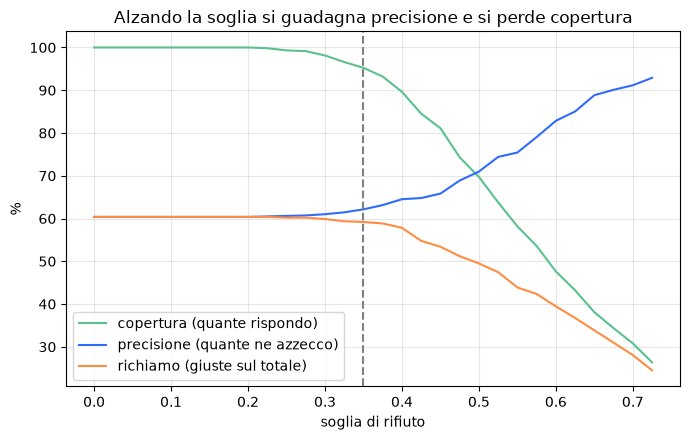

In [19]:
# La curva intera. E' lo scambio che dovete tarare voi, non un numero che vi diamo noi.
righe = []
for s in np.arange(0.0, 0.75, 0.025):
    acc_ = somiglianza >= s
    k = int(acc_.sum())
    if k == 0:
        continue
    righe.append((s, 100*k/len(yte),
                  100*(scelta[acc_] == yte[acc_]).float().mean().item(),
                  100*((scelta == yte) & acc_).float().sum().item()/len(yte)))
cur = pd.DataFrame(righe, columns=["soglia", "copertura", "precisione", "richiamo"])

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(cur.soglia, cur.copertura, label="copertura (quante rispondo)", color="#5ac18e")
ax.plot(cur.soglia, cur.precisione, label="precisione (quante ne azzecco)", color="#2f6bff")
ax.plot(cur.soglia, cur.richiamo, label="richiamo (giuste sul totale)", color="#ff8c42")
ax.axvline(SOGLIA_RIFIUTO, ls="--", c="gray")
ax.set_xlabel("soglia di rifiuto"); ax.set_ylabel("%"); ax.legend(); ax.grid(alpha=.3)
ax.set_title("Alzando la soglia si guadagna precisione e si perde copertura")
plt.tight_layout(); plt.show()

### 11:20 — Cambia il dato: la fusione

Il terzo gradino, e quello che avete chiesto di più. Tre cose da sapere prima di guardare
il numero.

**Dove si inietta.** Concatenare **dopo** il bottleneck: il numero può solo spostare il
confine di decisione. Concatenare **prima**: il numero può interagire con le feature visive.

**La scala del vettore è la trappola numero uno.** Dodici numeri contro 1280 di embedding:
se non li normalizzi e non li proietti, il numero non sparisce perché è poco informativo,
sparisce perché è poco numeroso. Qui sono standardizzati e proiettati a 32 dimensioni da un
piccolo MLP — e questo è il motivo per cui qualcosa si vede.

**Aggiungere una modalità può peggiorare le cose.** Non è un modo di dire: Wang, Tran e
Feiszli (CVPR 2020) mostrano che la migliore rete a modalità singola batte quella
multimodale in modo consistente, perché le due modalità vanno in overfitting a velocità
diverse. Se il numero qui sotto è negativo, è un risultato pubblicato, non un bug.

In [20]:
# ============================================================================
# PUNTO DI VARIAZIONE 3 — "dopo_bottleneck" oppure "prima_bottleneck"
# ============================================================================
PUNTO_DI_INIEZIONE = "dopo_bottleneck"
# ============================================================================

iniez = "dopo" if PUNTO_DI_INIEZIONE == "dopo_bottleneck" else "prima"

a_img, s_img, p_img = su_tre_semi(lambda: Testa(1280, arcface=True, margine=0.5))
a_fus, s_fus, p_fusa = su_tre_semi(
    lambda: Testa(1280, dim_geo=Gt.shape[1], arcface=True, margine=0.5, iniezione=iniez),
    Xtr, Gtr)

print(f"solo immagine                             {a_img:6.2f}%  +/- {s_img:.2f}")
print(f"immagine + 12 misure ({PUNTO_DI_INIEZIONE:<18}) {a_fus:6.2f}%  +/- {s_fus:.2f}")
print(f"\nguadagno medio: {a_fus - a_img:+.2f} punti")
confronta("il singolo confronto, seme 0", p_fusa, p_img)

# il modello a sola immagine del seme 0, che serve piu' avanti
solo_img = Testa(1280, arcface=True, margine=0.5); allena(solo_img, Xtr, ytr)
p_img = predici(solo_img, Xte)

solo immagine                              67.40%  +/- 0.21
immagine + 12 misure (dopo_bottleneck   )  67.80%  +/- 0.56

guadagno medio: +0.40 punti
il singolo confronto, seme 0                  67.01%   +20 -22  disaccordi  42  p=0.877  dentro il rumore


In [21]:
# La scala del vettore: cosa succede se NON lo si difende. Lo mostra il docente.
class FusaGrezza(nn.Module):
    '''Concatenazione brutale: 12 numeri accanto a 1280, senza proiezione.'''
    def __init__(self):
        super().__init__()
        self.bott = nn.Sequential(nn.Linear(1280 + 12, 128), nn.BatchNorm1d(128))
        self.testa = ArcFace(128, NCLASSI, 0.5, 32.0)
    def embedding(self, x, g=None): return self.bott(torch.cat([x, g], 1))
    def forward(self, x, g=None, y=None): return self.testa(self.embedding(x, g), y)

grezza = FusaGrezza(); allena(grezza, Xtr, ytr, Gtr)
confronta("fusione grezza, 12 numeri accanto a 1280", predici(grezza, Xte, Gte), p_img)
print()
print("Il vettore c'e', ma pesa l'1% dell'ingresso. La differenza fra questa riga e")
print("quella di sopra non e' il metodo di fusione: e' averlo proiettato a 32 dimensioni.")

fusione grezza, 12 numeri accanto a 1280      67.01%   +25 -27  disaccordi  52  p=0.890  dentro il rumore

Il vettore c'e', ma pesa l'1% dell'ingresso. La differenza fra questa riga e
quella di sopra non e' il metodo di fusione: e' averlo proiettato a 32 dimensioni.


---

# Passo 4 — Valutazione

Il pezzo più utile della giornata per chi deve decidere se mandare un modello in produzione.

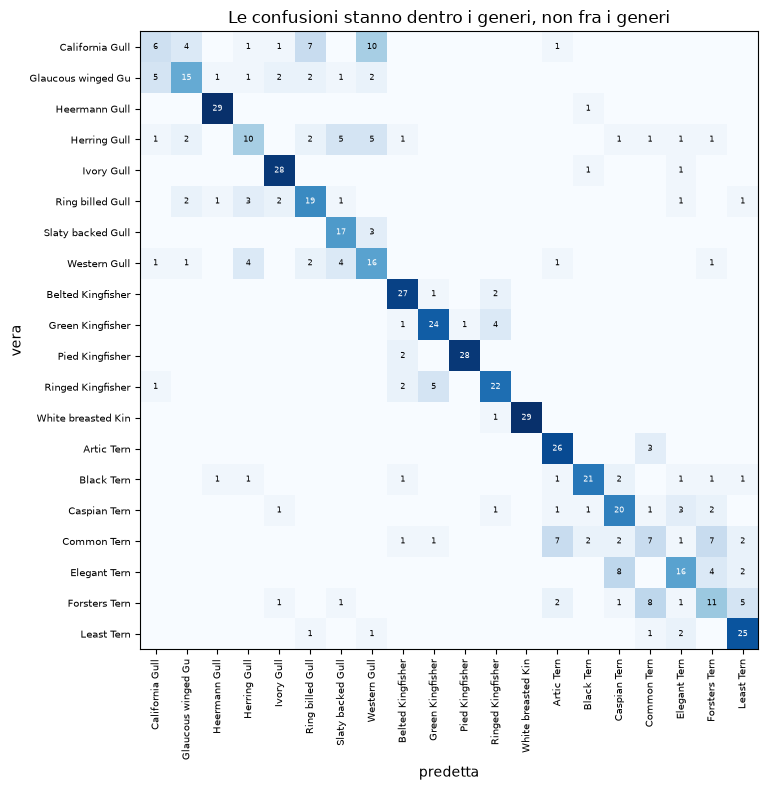

In [22]:
# La matrice 20x20 intera non si legge. Si guarda il blocco che conta.
from sklearn.metrics import confusion_matrix

M = confusion_matrix(yte, p_img, labels=range(NCLASSI))
etich = [n.split(".")[1].replace("_", " ")[:18] for n in nomi_classe]

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(M, cmap="Blues")
ax.set_xticks(range(NCLASSI)); ax.set_xticklabels(etich, rotation=90, fontsize=7)
ax.set_yticks(range(NCLASSI)); ax.set_yticklabels(etich, fontsize=7)
ax.set_xlabel("predetta"); ax.set_ylabel("vera")
for i in range(NCLASSI):
    for j in range(NCLASSI):
        if M[i, j]:
            ax.text(j, i, M[i, j], ha="center", va="center", fontsize=6,
                    color="white" if M[i, j] > M.max()/2 else "black")
ax.set_title("Le confusioni stanno dentro i generi, non fra i generi")
plt.tight_layout(); plt.show()

In [23]:
# Errore gerarchico: sbagliare genere e' peggio che sbagliare specie.
# Nel vostro caso: sbagliare famiglia di strumento e' peggio che sbagliare modello.
def genere(nome):
    return "Gull" if "Gull" in nome else "Tern" if "Tern" in nome else "Kingfisher"

gen = np.array([genere(n) for n in nomi_classe])
gv, gp = gen[yte.numpy()], gen[p_img.numpy()]

giuste       = (p_img == yte).float().mean().item()
genere_ok    = (gv == gp).mean()
print(f"specie giusta                      {100*giuste:6.2f}%")
print(f"genere giusto                      {100*genere_ok:6.2f}%")
print(f"specie sbagliata ma genere giusto  {100*(genere_ok-giuste):6.2f}%")
print(f"genere sbagliato                   {100*(1-genere_ok):6.2f}%")
print()
with torch.no_grad():
    logit = solo_img(Xte)
for k in (1, 3, 5):
    topk = logit.topk(k, dim=1).indices
    print(f"top-{k}: {100*(topk == yte[:, None]).any(1).float().mean().item():6.2f}%")

specie giusta                       67.35%
genere giusto                       95.75%
specie sbagliata ma genere giusto   28.40%
genere sbagliato                     4.25%

top-1:  67.35%
top-3:  86.22%
top-5:  90.48%


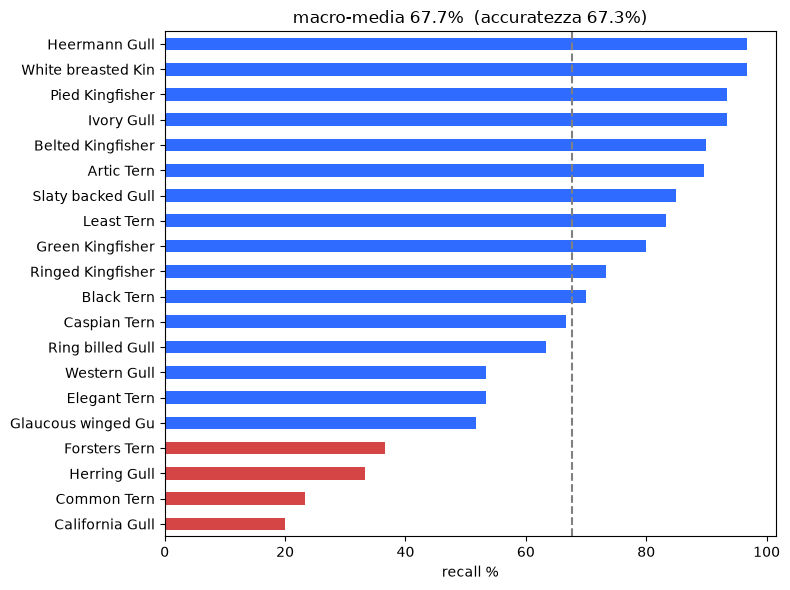

In [24]:
# Recall per classe: la media nasconde le classi difficili.
rec = pd.Series([100*(p_img[yte == k] == k).float().mean().item() for k in range(NCLASSI)],
                index=etich).sort_values()
fig, ax = plt.subplots(figsize=(8, 6))
rec.plot.barh(ax=ax, color=["#d64545" if v < 50 else "#2f6bff" for v in rec])
ax.axvline(rec.mean(), ls="--", c="gray")
ax.set_xlabel("recall %"); ax.set_title(f"macro-media {rec.mean():.1f}%  (accuratezza {100*giuste:.1f}%)")
plt.tight_layout(); plt.show()

## Quando un punto e mezzo è una differenza

Il test ha 588 immagini. **Una singola immagine vale 0,17 punti di accuratezza**: la
percentuale non è continua, si muove a scatti.

Verrebbe da concludere che una differenza di un punto e mezzo, cioè nove immagini, sia
rumore. **Non segue.** L'intervallo di confidenza vale per *un* modello isolato; noi
confrontiamo *due* modelli sullo **stesso** test set, e allora conta solo su quante immagini
i due sono in disaccordo. Due teste allenate sulle stesse feature congelate sono d'accordo
su quasi tutto, e in quel caso un punto e mezzo può benissimo essere reale.

In [25]:
print(f"una immagine vale {100/len(yte):.3f} punti")
print(f"un punto e mezzo sono {0.015*len(yte):.1f} immagini\n")

print("Intervallo di Wilson al 95% per UN modello:")
def wilson(k, n, z=1.96):
    p = k/n; d = 1 + z*z/n
    c = (p + z*z/(2*n))/d
    h = z*math.sqrt(p*(1-p)/n + z*z/(4*n*n))/d
    return c-h, c+h
for acc_ in (0.60, 0.70, 0.80, 0.90):
    lo, hi = wilson(round(acc_*len(yte)), len(yte))
    print(f"  {acc_:.0%} -> [{lo:.1%}, {hi:.1%}]  semiampiezza {100*(hi-lo)/2:.1f} punti")

print("\nMcNemar: quante immagini nette servono, in funzione dei disaccordi")
for disc in (20, 40, 60, 100):
    n_ = 1.96*math.sqrt(disc)
    print(f"  {disc:3d} disaccordi -> {n_:5.1f} immagini = {100*n_/len(yte):.1f} punti")
print("\nMeno i due modelli sono d'accordo, piu' grande deve essere la differenza")
print("per essere credibile. Il numero da guardare NON e' l'accuratezza.")

una immagine vale 0.170 punti
un punto e mezzo sono 8.8 immagini

Intervallo di Wilson al 95% per UN modello:
  60% -> [56.0%, 63.9%]  semiampiezza 3.9 punti
  70% -> [66.2%, 73.6%]  semiampiezza 3.7 punti
  80% -> [76.5%, 83.0%]  semiampiezza 3.2 punti
  90% -> [87.3%, 92.1%]  semiampiezza 2.4 punti

McNemar: quante immagini nette servono, in funzione dei disaccordi
   20 disaccordi ->   8.8 immagini = 1.5 punti
   40 disaccordi ->  12.4 immagini = 2.1 punti
   60 disaccordi ->  15.2 immagini = 2.6 punti
  100 disaccordi ->  19.6 immagini = 3.3 punti

Meno i due modelli sono d'accordo, piu' grande deve essere la differenza
per essere credibile. Il numero da guardare NON e' l'accuratezza.


## Grad-CAM, e perché non risponde alla domanda che vorreste

Tre righe di codice. Poi la cosa importante: **chiediamo la mappa della classe SBAGLIATA.**

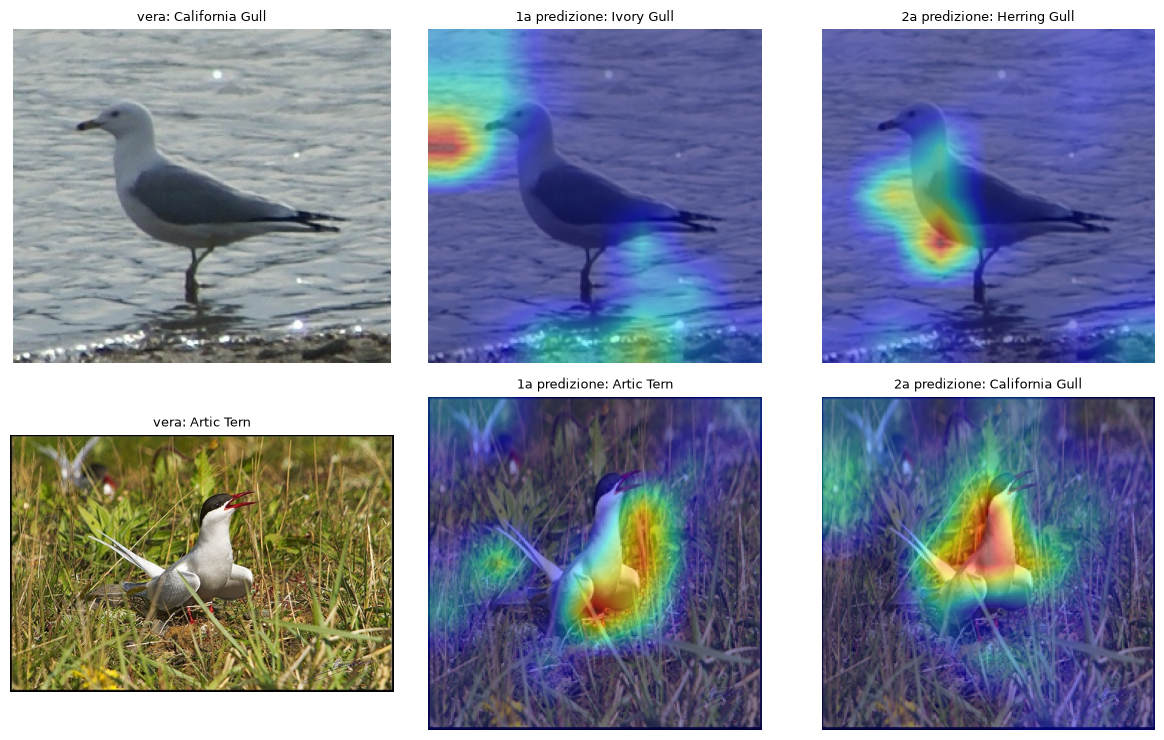

In [26]:
try:
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
except ImportError:
    !pip install -q grad-cam
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

class Completo(nn.Module):
    '''backbone congelato + la testa allenata: serve il modello intero per i gradienti.'''
    def __init__(self, testa):
        super().__init__()
        self.features, self.pool, self.testa = rete.features, rete.avgpool, testa
    def forward(self, x):
        return self.testa(torch.flatten(self.pool(self.features(x)), 1))

intero = Completo(solo_img).eval().cpu()
# Grad-CAM ha bisogno dei gradienti rispetto alle ATTIVAZIONI: il backbone e' congelato,
# quindi il grafo non verrebbe costruito e le mappe uscirebbero vuote. Si riaccende qui,
# solo per l'ispezione: nessun peso viene aggiornato.
for q in intero.parameters():
    q.requires_grad_(True)
cam = GradCAM(model=intero, target_layers=[intero.features[-1]])

# un gabbiano e una sterna dal test
sel = [dati[(dati.train == 0) & dati.nome.str.contains(g)].iloc[0] for g in ("Gull", "Tern")]
fig, assi = plt.subplots(2, 3, figsize=(12, 7.5))
for riga, r in zip(assi, sel):
    im = Image.open(D/"images"/r.file).convert("RGB")
    x = prep(im).unsqueeze(0)
    with torch.no_grad():
        top = intero(x)[0].topk(2).indices.tolist()
    riga[0].imshow(im); riga[0].set_title(f"vera: {etich[r.y]}", fontsize=9)
    for a, k, tit in zip(riga[1:], top, ("1a predizione", "2a predizione")):
        m_ = cam(input_tensor=x, targets=[ClassifierOutputTarget(k)])[0]
        a.imshow(im.resize((224, 224))); a.imshow(m_, cmap="jet", alpha=0.45)
        a.set_title(f"{tit}: {etich[k]}", fontsize=9)
    for a in riga: a.axis("off")
plt.tight_layout(); plt.show()

In [27]:
# Quanto si somigliano le due mappe? Misuriamolo su un campione del test.
rng = np.random.default_rng(0)
campione = rng.choice(np.where(dati.train.values == 0)[0], size=60, replace=False)
accordi = []
for j in campione:
    x = prep(Image.open(D/"images"/dati.file.iloc[j]).convert("RGB")).unsqueeze(0)
    with torch.no_grad():
        top = intero(x)[0].topk(2).indices.tolist()
    m1 = cam(input_tensor=x, targets=[ClassifierOutputTarget(top[0])])[0]
    m2 = cam(input_tensor=x, targets=[ClassifierOutputTarget(top[1])])[0]
    k = max(1, int(0.05 * m1.size))
    a = set(np.argpartition(m1.ravel(), -k)[-k:])
    b = set(np.argpartition(m2.ravel(), -k)[-k:])
    accordi.append(len(a & b) / k)
accordi = np.array(accordi)
print(f"accordo sul 5% di pixel piu' salienti, fra la mappa della 1a e della 2a classe:")
print(f"  media   {100*accordi.mean():.1f}%")
print(f"  mediana {100*np.median(accordi):.1f}%")
print(f"  immagini con accordo >= 50%: {100*(accordi >= .5).mean():.0f}%")

accordo sul 5% di pixel piu' salienti, fra la mappa della 1a e della 2a classe:
  media   4.4%
  mediana 0.0%
  immagini con accordo >= 50%: 2%


**Il nostro modello ha appena superato una prova che in letteratura molti modelli falliscono.**

C'è un difetto noto della famiglia CAM, l'**insensibilità alla classe**: le mappe della prima
e della seconda classe predetta vengono quasi identiche, il che vorrebbe dire che la mappa
non sta isolando l'evidenza di *quella* classe. Lo abbiamo misurato qui sopra e **da noi non
succede**: le due mappe si sovrappongono per una frazione minima.

Questa è la cosa da portarsi via, e non è il numero: è che **l'avete misurato invece di
fidarvi**. Il difetto è pubblicato su ImageNet, il nostro modello è un altro, e la risposta
è cambiata. Sul vostro sarà un'altra ancora, e si controlla con le dieci righe di sopra.

Una precisazione che vale la pena avere in tasca: **Grad-CAM passa i sanity check** di
Adebayo et al. (NeurIPS 2018). A fallirli — a produrre mappe bellissime anche su una rete con
i pesi a caso — è *Guided* Grad-CAM, che è quello che si trova nei blog e non è la stessa cosa.

## Ma restano due limiti, e il secondo è quello che vi riguarda

In [28]:
# LIMITE 1 — la risoluzione. La mappa non nasce a 224x224.
x = prep(Image.open(D/"images"/sel[0].file).convert("RGB")).unsqueeze(0)
with torch.no_grad():
    attivazioni = intero.features(x)
print(f"la mappa nasce a {tuple(attivazioni.shape[-2:])} e viene ingrandita a 224x224")
print(f"ogni cella copre circa {224//attivazioni.shape[-1]}x{224//attivazioni.shape[-1]} pixel.")
print("La differenza fra un gabbiano e una sterna sta spesso DENTRO una di quelle celle.")

la mappa nasce a (7, 7) e viene ingrandita a 224x224
ogni cella copre circa 32x32 pixel.
La differenza fra un gabbiano e una sterna sta spesso DENTRO una di quelle celle.


In [29]:
# LIMITE 2 — Grad-CAM non vede il ramo numerico. E' cieca meta' del modello.
# Quanto pesano le 12 misure? Con due modalita' bastano quattro addestramenti.
contributi = {"niente": 100.0 / NCLASSI}      # senza input: tirare a caso
print(f"  {'niente':20} {contributi['niente']:6.2f}%  (tirare a caso)")

mi = Testa(1280, arcface=True, margine=0.5); allena(mi, Xtr, ytr)
contributi["solo immagine"] = accuratezza(predici(mi, Xte), yte)
print(f"  {'solo immagine':20} {contributi['solo immagine']:6.2f}%")

mg = Testa(Gt.shape[1], arcface=True, margine=0.5); allena(mg, Gtr, ytr)
contributi["solo misure"] = accuratezza(predici(mg, Gte), yte)
print(f"  {'solo misure':20} {contributi['solo misure']:6.2f}%")

mf = Testa(1280, dim_geo=Gt.shape[1], arcface=True, margine=0.5, iniezione="dopo")
allena(mf, Xtr, ytr, Gtr)
contributi["immagine + misure"] = accuratezza(predici(mf, Xte, Gte), yte)
print(f"  {'immagine + misure':20} {contributi['immagine + misure']:6.2f}%")

base_ = contributi["niente"]
sh_img = 0.5*(contributi["solo immagine"]-base_) + 0.5*(contributi["immagine + misure"]-contributi["solo misure"])
sh_num = 0.5*(contributi["solo misure"]  -base_) + 0.5*(contributi["immagine + misure"]-contributi["solo immagine"])
print(f"\ncontributo di Shapley dell'immagine: {sh_img:6.2f} punti")
print(f"contributo di Shapley delle misure:  {sh_num:6.2f} punti")
print()
guadagno = contributi["immagine + misure"] - contributi["solo immagine"]
print(f"ma il guadagno che le misure aggiungono SOPRA l'immagine e' solo {guadagno:+.2f} punti.")
print()
print("I due numeri non sono in contraddizione, e insieme sono la risposta vera:")
print("le misure portano informazione (da sole fanno molto meglio del caso), ma e'")
print("informazione che l'immagine gia' contiene. Sono RIDONDANTI, non inutili.")
print()
print("Nel vostro caso e' l'opposto: una misura presa da uno strumento e' informazione")
print("che la foto NON puo' recuperare, e li' il guadagno sopra l'immagine e' quello vero.")
print("La regola: una feature numerica serve quando porta cio' che l'immagine non ha.")
print()
print("Con DUE modalita' le combinazioni sono quattro e Shapley si fa a mano.")
print("E' l'unico caso in cui non c'e' scusa per non farlo bene, e nessuna mappa")
print("di salienza vi avrebbe dato questi numeri.")

  niente                 5.00%  (tirare a caso)


  solo immagine         67.35%


  solo misure           22.11%


  immagine + misure     67.86%

contributo di Shapley dell'immagine:  54.05 punti
contributo di Shapley delle misure:    8.81 punti

ma il guadagno che le misure aggiungono SOPRA l'immagine e' solo +0.51 punti.

I due numeri non sono in contraddizione, e insieme sono la risposta vera:
le misure portano informazione (da sole fanno molto meglio del caso), ma e'
informazione che l'immagine gia' contiene. Sono RIDONDANTI, non inutili.

Nel vostro caso e' l'opposto: una misura presa da uno strumento e' informazione
che la foto NON puo' recuperare, e li' il guadagno sopra l'immagine e' quello vero.
La regola: una feature numerica serve quando porta cio' che l'immagine non ha.

Con DUE modalita' le combinazioni sono quattro e Shapley si fa a mano.
E' l'unico caso in cui non c'e' scusa per non farlo bene, e nessuna mappa
di salienza vi avrebbe dato questi numeri.


La mappa dice **dove** il gradiente è grande sull'immagine. Non dice **cosa** la rete ha
usato per decidere, e sul modello fuso non dice niente delle dodici misure — che pure
contribuiscono. Se qualcuno vi chiede «quanto pesa il numero rispetto alla foto», Grad-CAM
non è lo strumento: sono i quattro addestramenti qui sopra.

---

# Passo 5 — Produzione e vincoli

Quello che resta, in ordine di quanto costa ignorarlo.

1. **Il catalogo che cresce.** Con i prototipi una categoria nuova costa un vettore, non un
   riaddestramento. Con un classificatore chiuso costa una riga di pesi e un giro completo.
   Su 900 categorie l'indice esatto basta e avanza: 900 × 128 numeri sono meno di mezzo
   megabyte, la ricerca è microsecondi. **Gli indici approssimati vi servono sei ordini di
   grandezza più in là.**

2. **Un vincolo di distribuzione ha modificato il dato prima che il modello lo vedesse.**
   Le immagini che avete usato oggi sono ricompresse in JPEG qualità 95, perché la release
   doveva stare sotto i 100 MB. Nessuno ve lo aveva detto e il modello ci ha girato sopra
   tutta la mattina.

3. **CUB non ha una licenza standard**, e i suoi termini limitano l'uso a ricerca e didattica
   non commerciali. Per questo lo vedete nel notebook e non nel PDF che vi consegniamo. La
   frase che conta non è il nome della licenza: è *«questo non lo puoi mettere in
   produzione»*.